# Notebook 04 — Quimógrafos sintéticos (ground truth)

Generamos quimógrafos **sintéticos** con *ground truth* exacto, como punto de partida del tracking. Es lo acordado en la reunión del 2026-06-12 (ver `transcripts/2026-06-12 09-03-26_resumen.md`, puntos 6–7).

## Por qué sintéticos primero

Federico lo propuso y todos lo respaldaron: en vez de pelear de entrada con datos reales (ruido, ROI, autofluorescencia), generamos nosotros los quimógrafos. **La ventaja clave**: al dibujarlos sabemos exactamente dónde empieza y termina cada partícula y cómo se mueve momento a momento. Eso da un ground truth perfecto para medir cualquier algoritmo de tracking (KymoButler en el notebook 05, transformers más adelante).

> El acuerdo general: *si el punto de partida está mal, todo lo de arriba sobra*. Primero generar bien los sintéticos y validarlos.

## Spec del caso ideal (nivel 1, sin ruido) — punto 7 del acta

| Tipo | Cantidad | Notas |
|---|---|---|
| Estacionarias | 5 | líneas verticales puras |
| Anterógradas | 5 | con distintos movimientos |
| Retrógradas | 5 | con distintos movimientos |

Sobre un fondo negro, con partículas que **se cruzan** y con **movimiento estocástico** (corridas + **pausas**). Dos clases de verticales (Tomás): la **(a)** siempre vertical (estática pura, no interesa cinéticamente) y la **(b)** vertical *dentro* de un movimiento = **pausa**, que sí hay que contar. Por eso las móviles incluyen pausas y las estacionarias no.

## Convención de ejes

`quimografo[t, x]`: **filas = tiempo (frame)**, **columnas = posición (px a lo largo del axón)**. Es la misma orientación que `kimografo.generar_kimografo` (datos reales) y la que espera KymoButler. Fondo negro + estelas brillantes ⇒ KymoButler **no** invierte la imagen.

> La extracción de quimógrafos desde **video real** no se pierde: vive en `src/axonal_tracking/kimografo.py::generar_kimografo`. Este notebook se enfoca en el camino sintético.

El **nivel 2** (ruido de fondo + PSF) queda para más adelante; el generador ya lo soporta vía los parámetros `ruido` y `sigma_psf`.

---

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path("..") / "src"))
from axonal_tracking import kimografo_sintetico as ks
from axonal_tracking.parametros import PIXEL_SIZE_UM

# Colores por tipo (consistentes con el resto del proyecto).
COLORES = {"anterograda": "magenta", "retrograda": "cyan", "estacionaria": "yellow"}

# Salida: PNG + ground truth. Es el handoff al notebook 05.
DIR_SALIDA = Path("..") / "data" / "sinteticos"
NOMBRE = "sintetico_nivel1"
print(f"PIXEL_SIZE_UM = {PIXEL_SIZE_UM} um/px")
print(f"Salida -> {DIR_SALIDA.resolve()}/{NOMBRE}.png (+ _gt.csv, _resumen.csv)")

PIXEL_SIZE_UM = 0.107 um/px
Salida -> /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/data/sinteticos/sintetico_nivel1.png (+ _gt.csv, _resumen.csv)


---

## 1. Parámetros y generación

`T` y `L` se eligen **múltiplos de 16** para que KymoButler no tenga que redimensionar la imagen (así el ground truth queda alineado al píxel con la predicción). `seed` fija la reproducibilidad.

In [2]:
T, L = 256, 512        # tiempo (frames) x posicion (px), multiplos de 16
SEED = 42

particulas = ks.generar_particulas(
    T, L,
    n_estacionarias=5,
    n_anterogradas=5,
    n_retrogradas=5,
    rng=SEED,
)

# Caso ideal: sin ruido, sin PSF, estelas de 1 px.
kimo = ks.renderizar_kimografo(particulas, T, L, grosor=1, ruido=0.0, sigma_psf=0.0, rng=SEED)

print(f"Particulas: {len(particulas)}")
for tipo in ("estacionaria", "anterograda", "retrograda"):
    print(f"  {tipo:13s}: {sum(p.tipo == tipo for p in particulas)}")
print(f"Quimografo: shape={kimo.shape}, range=[{kimo.min():.2f}, {kimo.max():.2f}], "
      f"brillante={100*(kimo > 0.5).mean():.2f}%")

Particulas: 15
  estacionaria : 5
  anterograda  : 5
  retrograda   : 5
Quimografo: shape=(256, 512), range=[0.00, 1.00], brillante=2.64%


---

## 2. Visualización

A la izquierda, el quimógrafo crudo (lo que ve KymoButler). A la derecha, el mismo quimógrafo con el **ground truth** superpuesto, coloreado por tipo. Hay que ver:

- **5 verticales amarillas** (estacionarias puras).
- **5 magentas** que bajan hacia la derecha (anterógradas) y **5 cyan** hacia la izquierda (retrógradas).
- **Cruces** donde las trayectorias se intersecan.
- **Pausas**: tramos verticales *dentro* de una trayectoria móvil.

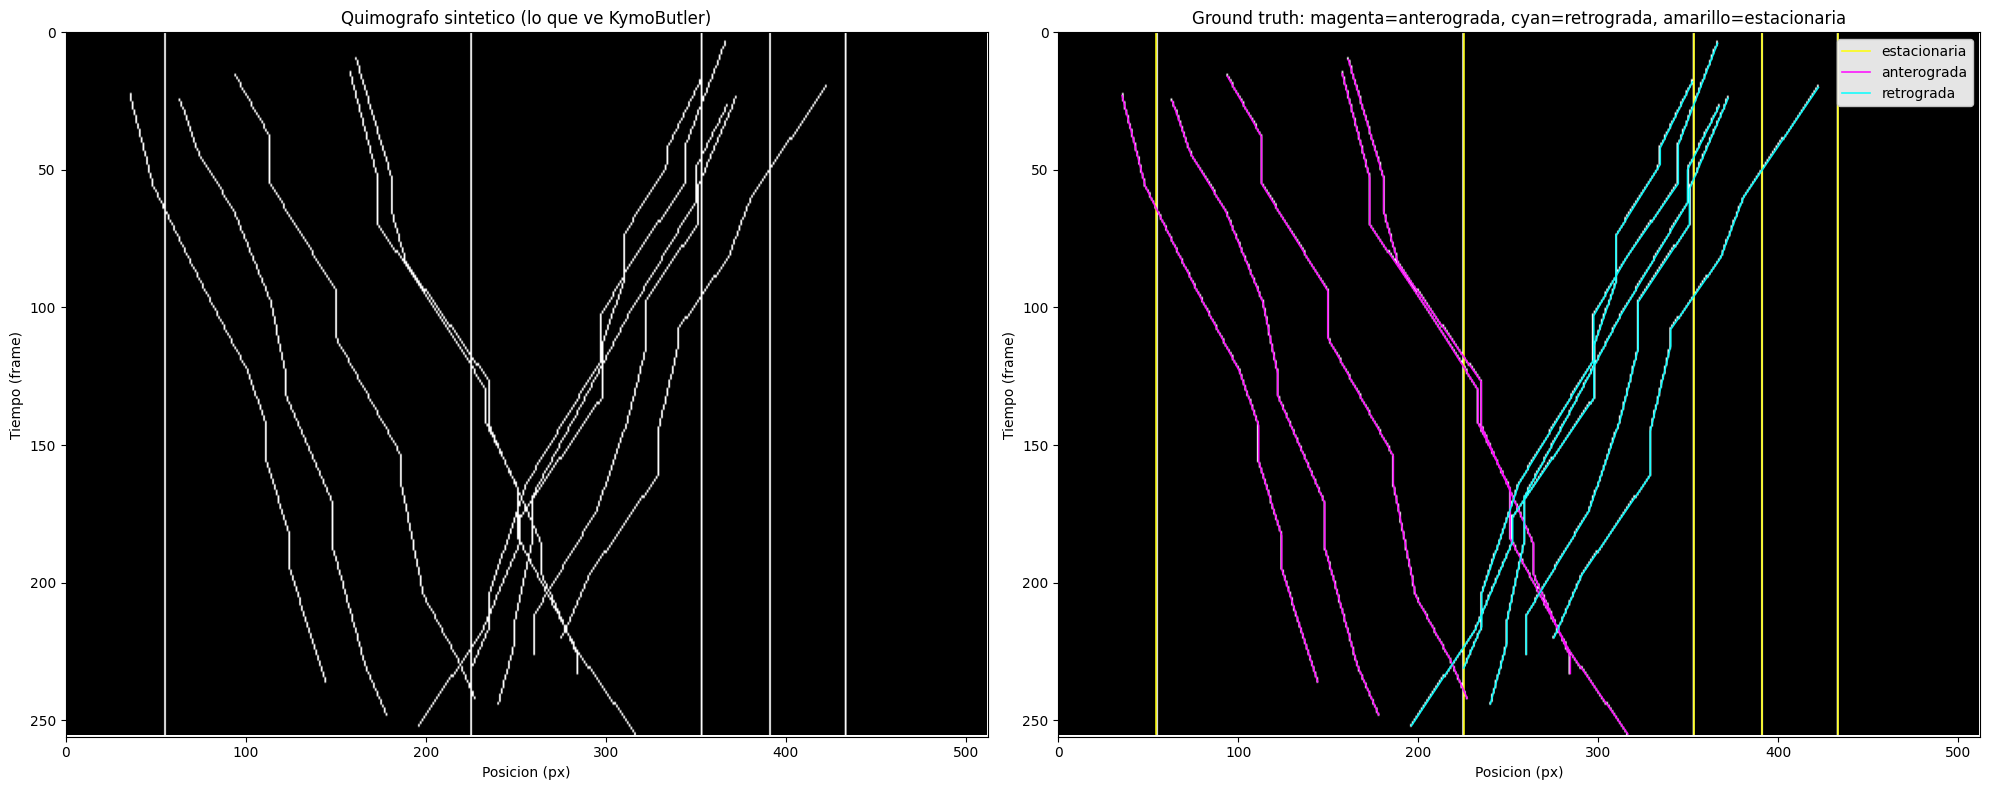

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].imshow(kimo, cmap="gray", aspect="auto", vmin=0, vmax=1)
axes[0].set_title("Quimografo sintetico (lo que ve KymoButler)")

axes[1].imshow(kimo, cmap="gray", aspect="auto", vmin=0, vmax=1)
filas_t = np.arange(T)
vistos = set()
for p in particulas:
    etiqueta = p.tipo if p.tipo not in vistos else None
    vistos.add(p.tipo)
    axes[1].plot(p.posiciones, filas_t, color=COLORES[p.tipo],
                 linewidth=1.2, alpha=0.9, label=etiqueta)
axes[1].set_title("Ground truth: magenta=anterograda, cyan=retrograda, amarillo=estacionaria")
axes[1].legend(loc="upper right", framealpha=0.9)

for ax in axes:
    ax.set_xlabel("Posicion (px)")
    ax.set_ylabel("Tiempo (frame)")
    ax.set_xlim(0, L)
    ax.set_ylim(T, 0)
plt.tight_layout()
plt.show()

---

## 3. Ground truth

Dos tablas:

- **Largo** (`gt`): una fila por `(particula, frame)` con la columna `x_px`. Es la posición momento a momento contra la que se mide el tracking.
- **Resumen**: ventana de vida, desplazamiento neto, número de **corridas** y de **pausas** por partícula.

In [4]:
import pandas as pd
pd.set_option("display.width", 140)

gt = ks.ground_truth_dataframe(particulas)
resumen = ks.resumen_particulas(particulas)

print(f"Ground truth (largo): {len(gt)} filas, columnas={list(gt.columns)}")
print(gt.head(6).to_string(index=False))
print()
print("Resumen por particula:")
print(resumen.to_string(index=False))
print()
moviles = resumen[resumen["tipo"] != "estacionaria"]
print(f"Moviles con >=1 pausa: {(moviles['n_pausas'] >= 1).sum()} / {len(moviles)}")
print("Direccion correcta (signo desplazamiento):",
      bool((resumen.loc[resumen.tipo == 'anterograda', 'desplazamiento_px'] > 0).all()
           and (resumen.loc[resumen.tipo == 'retrograda', 'desplazamiento_px'] < 0).all()))

Ground truth (largo): 3495 filas, columnas=['particula_id', 'tipo', 'frame', 'x_px']
 particula_id         tipo  frame       x_px
            0 estacionaria      0 391.108244
            0 estacionaria      1 391.108244
            0 estacionaria      2 391.108244
            0 estacionaria      3 391.108244
            0 estacionaria      4 391.108244
            0 estacionaria      5 391.108244

Resumen por particula:
 particula_id         tipo  t_inicio  t_fin   x_inicio      x_fin  desplazamiento_px  n_corridas  n_pausas
            0 estacionaria         0    255 391.108244 391.108244           0.000000           0         0
            1 estacionaria         0    255 225.244828 225.244828           0.000000           0         0
            2 estacionaria         0    255 433.005970 433.005970           0.000000           0         0
            3 estacionaria         0    255 353.197174 353.197174           0.000000           0         0
            4 estacionaria         0    2

---

## 4. Guardar (handoff al notebook 05)

Escribimos el PNG (fondo negro, lo que consume KymoButler) y los CSV de ground truth en `data/sinteticos/`. El notebook 05 los lee desde ahí.

In [5]:
rutas = ks.guardar_sintetico(kimo, particulas, DIR_SALIDA, nombre=NOMBRE)
for clave, ruta in rutas.items():
    print(f"  {clave:8s}: {ruta}")

  png     : ../data/sinteticos/sintetico_nivel1.png
  gt      : ../data/sinteticos/sintetico_nivel1_gt.csv
  resumen : ../data/sinteticos/sintetico_nivel1_resumen.csv


---

## Conclusión

Tenemos el quimógrafo sintético **ideal (nivel 1)** con su ground truth exacto:

- 5 estacionarias + 5 anterógradas + 5 retrógradas, con cruces y pausas.
- PNG (fondo negro) + CSV de posiciones momento a momento en `data/sinteticos/`.

### Próximos pasos

1. **Notebook 05**: correr **KymoButler** sobre este PNG y medir el tracking contra el ground truth (recall, error de posición, acierto de dirección, comportamiento en cruces).
2. **Nivel 2**: subir la dificultad con `ruido` y `sigma_psf` (ruido de fondo + PSF), y eventualmente partículas que aparecen/desaparecen.
3. Recién después, pasar a quimógrafos **reales** ya anotados (5–6) y comparar.

> Validar estos sintéticos con el laboratorio (Federico/Micaela) antes de seguir: *si el punto de partida está bien, el resto avanza.*